In [1]:
from notebooks.features.feature_extraction import load_all_features

loaded_features = load_all_features(version='oligo', n_jobs=-1, load_competition=False)

In [2]:
import pandas as pd

from notebooks.consts import OLIGO_CSV_PROCESSED_AVERAGED

data = pd.read_csv(OLIGO_CSV_PROCESSED_AVERAGED)

In [3]:
# This will only keep rows where BOTH index_oligo AND sense_start match
final_data = pd.merge(loaded_features, data, on=['index_oligo', 'sense_start'])

if len(final_data) != len(data):
    raise ValueError("Mismatch detected in 'sense_start' during merge!")

In [4]:
from tauso.data.consts import *

features_to_ignore = ['index_oligo', INHIBITION, 'inhibition_percent', 'dosage']

# Note: Assuming 'merged_df' is your final dataframe. If you are just using 'data', change this to 'data'.
features = [
               col for col in final_data.select_dtypes(include=['number']).columns
               if col not in features_to_ignore
           ] + [VOLUME]

# Ensure uniqueness
features = sorted(list(set(features)))

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr
import warnings

# Suppress the specific XGBoost device mismatch warning
warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")

# ---------------------------------------------------------
# 1. Strict Splitting by CELL_LINE (Row-Count Balanced)
# ---------------------------------------------------------
final_data['cohort_id'] = final_data[CANONICAL_GENE].astype(str) + "_" + final_data[CELL_LINE].astype(str)

def balanced_group_split(df, group_col, target_props=(0.70, 0.15, 0.15), random_state=42):
    """Greedily assigns groups to bins to achieve target row proportions."""
    np.random.seed(random_state)
    group_sizes = df[group_col].value_counts().to_dict()

    # Shuffle groups first to prevent alphabetical bias, then sort by size descending
    # (Packing largest groups first ensures the best fit)
    groups = list(group_sizes.keys())
    np.random.shuffle(groups)
    groups.sort(key=lambda g: group_sizes[g], reverse=True)

    targets = [len(df) * p for p in target_props]
    current = [0, 0, 0]
    assigned = [[], [], []]

    for g in groups:
        size = group_sizes[g]
        # Assign group to the bin with the largest current deficit
        best_bin = np.argmax([targets[i] - current[i] for i in range(3)])
        assigned[best_bin].append(g)
        current[best_bin] += size

    return assigned[0], assigned[1], assigned[2]

# Execute the balanced split
train_groups, val_groups, test_groups = balanced_group_split(
    final_data,
    CELL_LINE,
    target_props=(0.70, 0.15, 0.15) # Adjust these targets if you want 80/10/10
)

# Build the DataFrames using the assigned groups
train_df = final_data[final_data[CELL_LINE].isin(train_groups)].copy().sort_values('cohort_id').reset_index(drop=True)
val_df = final_data[final_data[CELL_LINE].isin(val_groups)].copy().sort_values('cohort_id').reset_index(drop=True)
test_df = final_data[final_data[CELL_LINE].isin(test_groups)].copy().sort_values('cohort_id').reset_index(drop=True)

# Generate contiguous QIDs for ranking
train_df['qid'] = pd.factorize(train_df['cohort_id'])[0]
val_df['qid'] = pd.factorize(val_df['cohort_id'])[0]
test_df['qid'] = pd.factorize(test_df['cohort_id'])[0]

# Keep targets as raw continuous floats
X_train, y_train = train_df[features].values, train_df[INHIBITION].values
X_val, y_val = val_df[features].values, val_df[INHIBITION].values
X_test, y_test = test_df[features].values, test_df[INHIBITION].values

qid_train, qid_val, qid_test = train_df['qid'].values, val_df['qid'].values, test_df['qid'].values

print(f"Split sizes -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Split sizes -> Train: 74781, Val: 16023, Test: 15993


In [6]:
def print_split_stats(split_name, df, group_col='cohort_id'):
    print(f"================ {split_name.upper()} SPLIT ================")

    # 3. Size of each and amount of groups
    num_rows = len(df)
    num_groups = df[group_col].nunique()
    print(f"Total Rows: {num_rows}")
    print(f"Distinct Cell Lines (Groups): {num_groups}")

    print("-" * 40)
    # 1. is_hepa in every group
    print("Distribution of 'is_hepa':")
    # Using dropna=False to catch if any nulls slipped through
    print(df['is_hepa'].value_counts(dropna=False).to_string())

    print("-" * 40)
    # 2. Chemistries (MODIFICATION) in every group
    print("Distribution of Chemistries ('MODIFICATION'):")
    print(df[MODIFICATION].value_counts(dropna=False).to_string())
    print("==================================================\n")

# Execute the reporting function for each split
print_split_stats("Train", train_df, group_col='cohort_id')
print_split_stats("Validation", val_df, group_col='cohort_id')
print_split_stats("Test", test_df, group_col='cohort_id')

================ TRAIN SPLIT ================
Total Rows: 74781
Distinct Cell Lines (Groups): 43
----------------------------------------
Distribution of 'is_hepa':
is_hepa
0.0    62633
1.0    12148
----------------------------------------
Distribution of Chemistries ('MODIFICATION'):
Modification
MOE/5-methylcytosines/deoxy    45511
cEt/5-methylcytosines/deoxy    29270

================ VALIDATION SPLIT ================
Total Rows: 16023
Distinct Cell Lines (Groups): 27
----------------------------------------
Distribution of 'is_hepa':
is_hepa
1.0    11144
0.0     4879
----------------------------------------
Distribution of Chemistries ('MODIFICATION'):
Modification
MOE/5-methylcytosines/deoxy    9366
cEt/5-methylcytosines/deoxy    6657

================ TEST SPLIT ================
Total Rows: 15993
Distinct Cell Lines (Groups): 6
----------------------------------------
Distribution of 'is_hepa':
is_hepa
0.0    10786
1.0     5207
----------------------------------------
Distributio

In [7]:
# Run this in your TAUSO script
test_df.to_csv('tauso_strict_test_set.csv', index=False)
print("Test set exported for OligoAI comparison!")

Test set exported for OligoAI comparison!


In [8]:
# ---------------------------------------------------------
# 2. Fast Spearman Setup (Pre-computing array indices)
# ---------------------------------------------------------
def precompute_eval_groups(df, y_true_arr):
    groups = []
    for cohort, group in df.groupby('cohort_id'):
        if len(group) >= 50:
            groups.append((group.index.values, y_true_arr[group.index.values]))
    return groups


val_eval_groups = precompute_eval_groups(val_df, y_val)
test_eval_groups = precompute_eval_groups(test_df, y_test)

warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")

# ---------------------------------------------------------
# 1. THE SPEED FIX: Load data into GPU-native DMatrix ONCE
# ---------------------------------------------------------
print("Loading data into GPU memory...")

# For L2 Regression (No QIDs needed)
dtrain_l2 = xgb.DMatrix(X_train, label=y_train)
dval_l2 = xgb.DMatrix(X_val, label=y_val)

# For Ranking (QIDs required)
dtrain_rank = xgb.DMatrix(X_train, label=y_train, qid=qid_train)
dval_rank = xgb.DMatrix(X_val, label=y_val, qid=qid_val)

print("Data loaded to GPU. Ready for lightning-fast trials.")


# ---------------------------------------------------------
# 2. Optuna Objective Functions (Native API)
# ---------------------------------------------------------
def get_xgb_params(trial, objective):
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'objective': objective,
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    # Prevent float target overflow in rankers
    if 'rank' in objective:
        params['ndcg_exp_gain'] = False

    return params


def calculate_fast_spearman(preds, eval_groups):
    """Calculates Spearman instantly using pre-mapped numpy array indices"""
    spearmans = []
    for idxs, true_vals in eval_groups:
        corr, _ = spearmanr(true_vals, preds[idxs])
        if not np.isnan(corr):
            spearmans.append(corr)
    return np.nanmean(spearmans) if spearmans else 0.0


def objective_l2(trial):
    params = get_xgb_params(trial, 'reg:squarederror')
    num_boost_round = trial.suggest_int('num_boost_round', 200, 1500, step=100)

    # Native Training: Zero CPU/GPU memory bouncing
    bst = xgb.train(
        params,
        dtrain_l2,
        num_boost_round=num_boost_round,
        evals=[(dval_l2, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # Predict directly using the GPU DMatrix
    preds = bst.predict(dval_l2)
    return calculate_fast_spearman(preds, val_eval_groups)


def objective_ranking(trial, rank_objective):
    params = get_xgb_params(trial, rank_objective)
    num_boost_round = trial.suggest_int('num_boost_round', 200, 1500, step=100)

    # Native Training: Zero CPU/GPU memory bouncing
    bst = xgb.train(
        params,
        dtrain_rank,
        num_boost_round=num_boost_round,
        evals=[(dval_rank, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # Predict directly using the GPU DMatrix
    preds = bst.predict(dval_rank)
    return calculate_fast_spearman(preds, val_eval_groups)


# ---------------------------------------------------------
# 3. Execution
# ---------------------------------------------------------
N_TRIALS = 50

print("\nStarting L2 Regression Study...")
study_l2 = optuna.create_study(direction="maximize")
study_l2.optimize(objective_l2, n_trials=N_TRIALS, show_progress_bar=True)

print("\nStarting NDCG Ranking Study...")
study_ndcg = optuna.create_study(direction="maximize")
study_ndcg.optimize(lambda trial: objective_ranking(trial, 'rank:ndcg'), n_trials=N_TRIALS, show_progress_bar=True)

print("\nStarting Pairwise Ranking Study...")
study_pairwise = optuna.create_study(direction="maximize")
study_pairwise.optimize(lambda trial: objective_ranking(trial, 'rank:pairwise'), n_trials=N_TRIALS,
                        show_progress_bar=True)

df_results_l2 = study_l2.trials_dataframe()
df_results_ndcg = study_ndcg.trials_dataframe()
df_results_pairwise = study_pairwise.trials_dataframe()

Loading data into GPU memory...


[I 2026-04-05 14:25:37,543] A new study created in memory with name: no-name-2c4a3c9a-691f-4f54-8b3b-2c0e6c6eda08


Data loaded to GPU. Ready for lightning-fast trials.

Starting L2 Regression Study...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-05 14:25:39,163] Trial 0 finished with value: 0.37781981446736745 and parameters: {'max_depth': 9, 'learning_rate': 0.06527864680461501, 'subsample': 0.5792744575546981, 'colsample_bytree': 0.561786374467725, 'min_child_weight': 25, 'gamma': 0.02706573732685323, 'reg_alpha': 7.971935779634329e-06, 'reg_lambda': 0.0006457186990421473, 'num_boost_round': 400}. Best is trial 0 with value: 0.37781981446736745.
[I 2026-04-05 14:25:48,910] Trial 1 finished with value: 0.3932215154216242 and parameters: {'max_depth': 8, 'learning_rate': 0.0040148529693693905, 'subsample': 0.7516802086019161, 'colsample_bytree': 0.8266407757549161, 'min_child_weight': 6, 'gamma': 5.779023675581764e-06, 'reg_alpha': 0.152699016597993, 'reg_lambda': 4.534963797776643, 'num_boost_round': 900}. Best is trial 1 with value: 0.3932215154216242.
[I 2026-04-05 14:25:50,107] Trial 2 finished with value: 0.42257220675759133 and parameters: {'max_depth': 6, 'learning_rate': 0.06425613956255444, 'subsample': 0.6

...

[I 2026-04-05 14:29:22,774] Trial 0 finished with value: 0.13329466198589648 and parameters: {'max_depth': 12, 'learning_rate': 0.01912197361478219, 'subsample': 0.6530675426865435, 'colsample_bytree': 0.6828939003875598, 'min_child_weight': 38, 'gamma': 4.228403906540713e-06, 'reg_alpha': 9.229793890138451e-05, 'reg_lambda': 0.07175822135626178, 'num_boost_round': 800}. Best is trial 0 with value: 0.13329466198589648.
[I 2026-04-05 14:29:23,149] Trial 1 finished with value: 0.16936303651603787 and parameters: {'max_depth': 12, 'learning_rate': 0.00266264314710939, 'subsample': 0.6774171779521659, 'colsample_bytree': 0.5664831250815454, 'min_child_weight': 26, 'gamma': 2.84827632564595e-05, 'reg_alpha': 1.5891060253268193e-06, 'reg_lambda': 0.00048199033291136727, 'num_boost_round': 1300}. Best is trial 1 with value: 0.16936303651603787.
[I 2026-04-05 14:29:23,553] Trial 2 finished with value: 0.18635562235981445 and parameters: {'max_depth': 6, 'learning_rate': 0.0016921250142787378, 

[I 2026-04-05 14:30:24,227] A new study created in memory with name: no-name-869072b4-3f85-42f4-8f6e-ed75b9eec69c


[I 2026-04-05 14:30:24,225] Trial 49 finished with value: 0.3501392262977404 and parameters: {'max_depth': 11, 'learning_rate': 0.09788515996690927, 'subsample': 0.8577668961093472, 'colsample_bytree': 0.5947066519803887, 'min_child_weight': 7, 'gamma': 3.785588734415809e-08, 'reg_alpha': 3.1239578778616642e-06, 'reg_lambda': 6.656533293509033, 'num_boost_round': 900}. Best is trial 44 with value: 0.3897602768514951.

Starting Pairwise Ranking Study...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-05 14:30:25,577] Trial 0 finished with value: 0.31064853232595513 and parameters: {'max_depth': 10, 'learning_rate': 0.09277339822619396, 'subsample': 0.6659160475953905, 'colsample_bytree': 0.6020631819296312, 'min_child_weight': 25, 'gamma': 0.003867262526200276, 'reg_alpha': 2.2753562464595004e-07, 'reg_lambda': 2.9337538313778074e-07, 'num_boost_round': 1400}. Best is trial 0 with value: 0.31064853232595513.
[I 2026-04-05 14:30:27,470] Trial 1 finished with value: 0.35460841782230446 and parameters: {'max_depth': 6, 'learning_rate': 0.130525891414001, 'subsample': 0.8548606388599773, 'colsample_bytree': 0.7254153560634222, 'min_child_weight': 19, 'gamma': 0.01640461165519636, 'reg_alpha': 0.0008588462668863519, 'reg_lambda': 0.5302483065400274, 'num_boost_round': 700}. Best is trial 1 with value: 0.35460841782230446.
[I 2026-04-05 14:30:28,884] Trial 2 finished with value: 0.3099385816185919 and parameters: {'max_depth': 11, 'learning_rate': 0.27912367410455474, 'subsamp

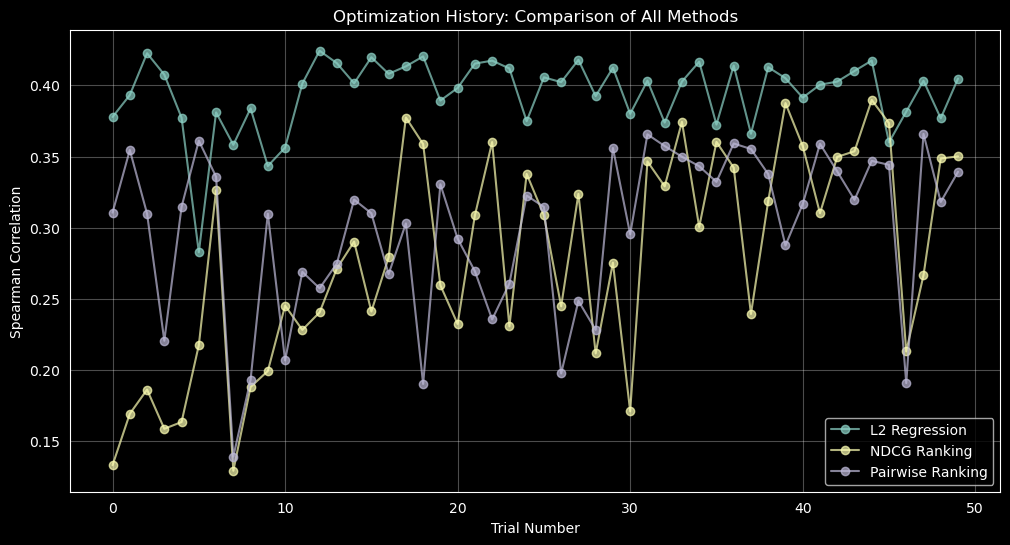


--- Evaluating L2 Model on Unseen Cell Lines (Test Set) ---


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:32:02] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Spearman Correlation (L2 Model): 0.3028

--- Evaluating NDCG Model on Unseen Cell Lines (Test Set) ---


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:32:06] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Spearman Correlation (NDCG Model): 0.2657

--- Evaluating Pairwise Model on Unseen Cell Lines (Test Set) ---


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:32:10] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Spearman Correlation (Pairwise Model): 0.3035


In [9]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 5. Combined Plotting Function
# ---------------------------------------------------------
def plot_combined_history(df_dict):
    plt.figure(figsize=(12, 6))

    # Loop through the dictionary and plot each method's trial values
    for name, df in df_dict.items():
        # Using marker='o' and linestyle='-' to show the path of the trials
        plt.plot(df['number'], df['value'], marker='o', linestyle='-', alpha=0.7, label=name)

    plt.title("Optimization History: Comparison of All Methods")
    plt.xlabel("Trial Number")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Pass all results into the new combined plotting function
plot_combined_history({
    "L2 Regression": df_results_l2,
    "NDCG Ranking": df_results_ndcg,
    "Pairwise Ranking": df_results_pairwise
})


# ---------------------------------------------------------
# 6. Evaluate Utility on Final Test Set
# ---------------------------------------------------------
def evaluate_final_utility(study, objective, name):
    print(f"\n--- Evaluating {name} on Unseen Cell Lines (Test Set) ---")
    best_params = study.best_params
    best_params['tree_method'] = 'hist'
    best_params['device'] = 'cuda'
    best_params['objective'] = objective

    # FIXED: Ensure linear gain is applied for final evaluation on BOTH rankers
    if 'rank' in objective:
        best_params['ndcg_exp_gain'] = False

    if "reg" in objective:
        model = xgb.XGBRegressor(**best_params, random_state=42)
        model.fit(X_train, y_train)
    else:
        model = xgb.XGBRanker(**best_params, random_state=42)
        model.fit(X_train, y_train, qid=qid_train)

    preds = model.predict(X_test)
    final_spearman = calculate_fast_spearman(preds, test_eval_groups)

    print(f"Mean Spearman Correlation ({name}): {final_spearman:.4f}")
    return final_spearman


spearman_l2 = evaluate_final_utility(study_l2, 'reg:squarederror', "L2 Model")
spearman_ndcg = evaluate_final_utility(study_ndcg, 'rank:ndcg', "NDCG Model")
spearman_pairwise = evaluate_final_utility(study_pairwise, 'rank:pairwise', "Pairwise Model")

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# --- SELECTION THRESHOLDS ---
PARSIMONY_TOLERANCE = 0.015  # Accept a model if it is within 0.015 of the absolute maximum Spearman
EARLY_STOP_DROP = 0.05  # Stop the loop if performance drops 0.05 below the best seen so far
# ----------------------------

# 1. Fast Tracking Functions & Setup
X_train_np, y_train_np = train_df[features].values, train_df[INHIBITION].values
X_val_np, y_val_np = val_df[features].values, val_df[INHIBITION].values
X_test_np, y_test_np = test_df[features].values, test_df[INHIBITION].values

feat_to_idx = {feat: i for i, feat in enumerate(features)}


def get_large_cohort_indices(df):
    return [group.index.values for _, group in df.groupby('cohort_id') if len(group) >= 50]


train_eval_idx = get_large_cohort_indices(train_df)
val_eval_idx = get_large_cohort_indices(val_df)
test_eval_idx = get_large_cohort_indices(test_df)


def calculate_metrics(preds, y_true, eval_groups):
    spearmans, top_1_means, top_5_means = [], [], []
    for idxs in eval_groups:
        t_vals = y_true[idxs]
        p_vals = preds[idxs]

        corr, _ = spearmanr(t_vals, p_vals)
        if not np.isnan(corr):
            spearmans.append(corr)

        n = len(t_vals)
        k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))
        sorted_indices = np.argsort(p_vals)[::-1]

        top_1_means.append(np.mean(t_vals[sorted_indices[:k1]]))
        top_5_means.append(np.mean(t_vals[sorted_indices[:k5]]))

    return {
        'spearman': np.nanmean(spearmans) if spearmans else 0.0,
        'top1_inhibition': np.nanmean(top_1_means) if top_1_means else 0.0,
        'top5_inhibition': np.nanmean(top_5_means) if top_5_means else 0.0
    }


# 2. Extract Best Optuna Parameters
best_l2_params = study_l2.best_params.copy()
best_l2_params.update({'tree_method': 'hist', 'device': 'cuda', 'objective': 'reg:squarederror'})
num_rounds = best_l2_params.pop('num_boost_round', best_l2_params.pop('n_estimators', 1000))

# 3. Execution Loop
current_features = list(features)
selection_history = []
max_spearman_seen = -1.0

total_iters = ((len(current_features) - 100) // 5) + 100 if len(current_features) > 100 else len(current_features)
pbar = tqdm(total=total_iters, desc="Dropping Features")

while len(current_features) > 0:
    curr_idxs = [feat_to_idx[f] for f in current_features]

    dtrain = xgb.DMatrix(X_train_np[:, curr_idxs], label=y_train_np, feature_names=current_features)
    dval = xgb.DMatrix(X_val_np[:, curr_idxs], label=y_val_np, feature_names=current_features)
    dtest = xgb.DMatrix(X_test_np[:, curr_idxs], label=y_test_np, feature_names=current_features)

    bst = xgb.train(
        best_l2_params, dtrain, num_boost_round=num_rounds,
        evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False
    )

    metrics_train = calculate_metrics(bst.predict(dtrain), y_train_np, train_eval_idx)
    metrics_val = calculate_metrics(bst.predict(dval), y_val_np, val_eval_idx)
    metrics_test = calculate_metrics(bst.predict(dtest), y_test_np, test_eval_idx)

    val_spear = metrics_val['spearman']
    if val_spear > max_spearman_seen:
        max_spearman_seen = val_spear

    step_data = {
        'num_features': len(current_features),
        'features_list': list(current_features),
        'train_spearman': metrics_train['spearman'],
        'train_top1': metrics_train['top1_inhibition'],
        'train_top5': metrics_train['top5_inhibition'],
        'val_spearman': val_spear,
        'val_top1': metrics_val['top1_inhibition'],
        'val_top5': metrics_val['top5_inhibition'],
        'test_spearman': metrics_test['spearman'],
        'test_top1': metrics_test['top1_inhibition'],
        'test_top5': metrics_test['top5_inhibition'],
    }

    # EARLY STOPPING CHECK
    if val_spear < (max_spearman_seen - EARLY_STOP_DROP):
        print(
            f"\n[Early Stop] Val Spearman dropped to {val_spear:.4f} (Peak was {max_spearman_seen:.4f}). Halting to save time.")
        step_data['dropped_features'] = []
        selection_history.append(step_data)
        break

    if len(current_features) == 1:
        step_data['dropped_features'] = current_features
        selection_history.append(step_data)
        pbar.update(1)
        break

    imp_dict = bst.get_score(importance_type='gain')
    feat_importances = {f: imp_dict.get(f, 0.0) for f in current_features}
    sorted_feats = sorted(feat_importances.items(), key=lambda x: x[1])

    drop_n = 5 if len(current_features) > 100 else 1
    drop_n = min(drop_n, len(current_features) - 1)
    feats_to_drop = [x[0] for x in sorted_feats[:drop_n]]

    step_data['dropped_features'] = feats_to_drop
    selection_history.append(step_data)

    print(f"\n[Features: {len(current_features)} -> {len(current_features) - drop_n}]")
    print(
        f"  Train -> Spear: {metrics_train['spearman']:.4f} | Top 1%: {metrics_train['top1_inhibition']:.2f} | Top 5%: {metrics_train['top5_inhibition']:.2f}")
    print(
        f"  Val   -> Spear: {val_spear:.4f} | Top 1%: {metrics_val['top1_inhibition']:.2f} | Top 5%: {metrics_val['top5_inhibition']:.2f}")
    print(
        f"  Test  -> Spear: {metrics_test['spearman']:.4f} | Top 1%: {metrics_test['top1_inhibition']:.2f} | Top 5%: {metrics_test['top5_inhibition']:.2f}")

    current_features = [f for f in current_features if f not in feats_to_drop]
    pbar.update(1)

pbar.close()

# 4. PARSIMONIOUS SELECTION
df_backward_selection = pd.DataFrame(selection_history)

absolute_peak = df_backward_selection['val_spearman'].max()
threshold = absolute_peak - PARSIMONY_TOLERANCE

# Keep only iterations that are within the tolerance of the absolute peak
candidates = df_backward_selection[df_backward_selection['val_spearman'] >= threshold]

# Out of those highly-performing subsets, pick the one with the MINIMUM number of features
best_row = candidates.loc[candidates['num_features'].idxmin()]
abs_peak_row = df_backward_selection.loc[df_backward_selection['val_spearman'].idxmax()]

print("\n" + "=" * 50)
print(f"🏆 OPTIMAL PARSIMONIOUS MODEL FOUND")
print("=" * 50)
print(f"Absolute Peak Spearman : {absolute_peak:.4f} (at {abs_peak_row['num_features']} features)")
print(f"Parsimonious Selection : {best_row['val_spearman']:.4f} (at {best_row['num_features']} features)")
print(f"Unseen Test Spearman   : {best_row['test_spearman']:.4f}")
print(f"Test Top 1% True Inhib : {best_row['test_top1']:.2f}")


Dropping Features:   0%|          | 0/206 [00:00<?, ?it/s]


[Features: 631 -> 626]
  Train -> Spear: 0.7218 | Top 1%: 84.47 | Top 5%: 79.58
  Val   -> Spear: 0.4243 | Top 1%: 69.99 | Top 5%: 69.60
  Test  -> Spear: 0.3988 | Top 1%: 52.86 | Top 5%: 54.05

[Features: 626 -> 621]
  Train -> Spear: 0.6660 | Top 1%: 83.35 | Top 5%: 77.81
  Val   -> Spear: 0.4175 | Top 1%: 67.78 | Top 5%: 68.46
  Test  -> Spear: 0.3688 | Top 1%: 53.19 | Top 5%: 52.74

[Features: 621 -> 616]
  Train -> Spear: 0.6565 | Top 1%: 82.16 | Top 5%: 77.18
  Val   -> Spear: 0.4038 | Top 1%: 69.94 | Top 5%: 67.52
  Test  -> Spear: 0.3755 | Top 1%: 52.06 | Top 5%: 51.51

[Features: 616 -> 611]
  Train -> Spear: 0.6770 | Top 1%: 83.40 | Top 5%: 78.24
  Val   -> Spear: 0.4225 | Top 1%: 69.64 | Top 5%: 69.01
  Test  -> Spear: 0.3808 | Top 1%: 51.31 | Top 5%: 52.28

[Features: 611 -> 606]
  Train -> Spear: 0.6876 | Top 1%: 83.16 | Top 5%: 78.50
  Val   -> Spear: 0.4200 | Top 1%: 71.24 | Top 5%: 69.14
  Test  -> Spear: 0.3859 | Top 1%: 52.65 | Top 5%: 53.61

[Features: 606 -> 601]
 

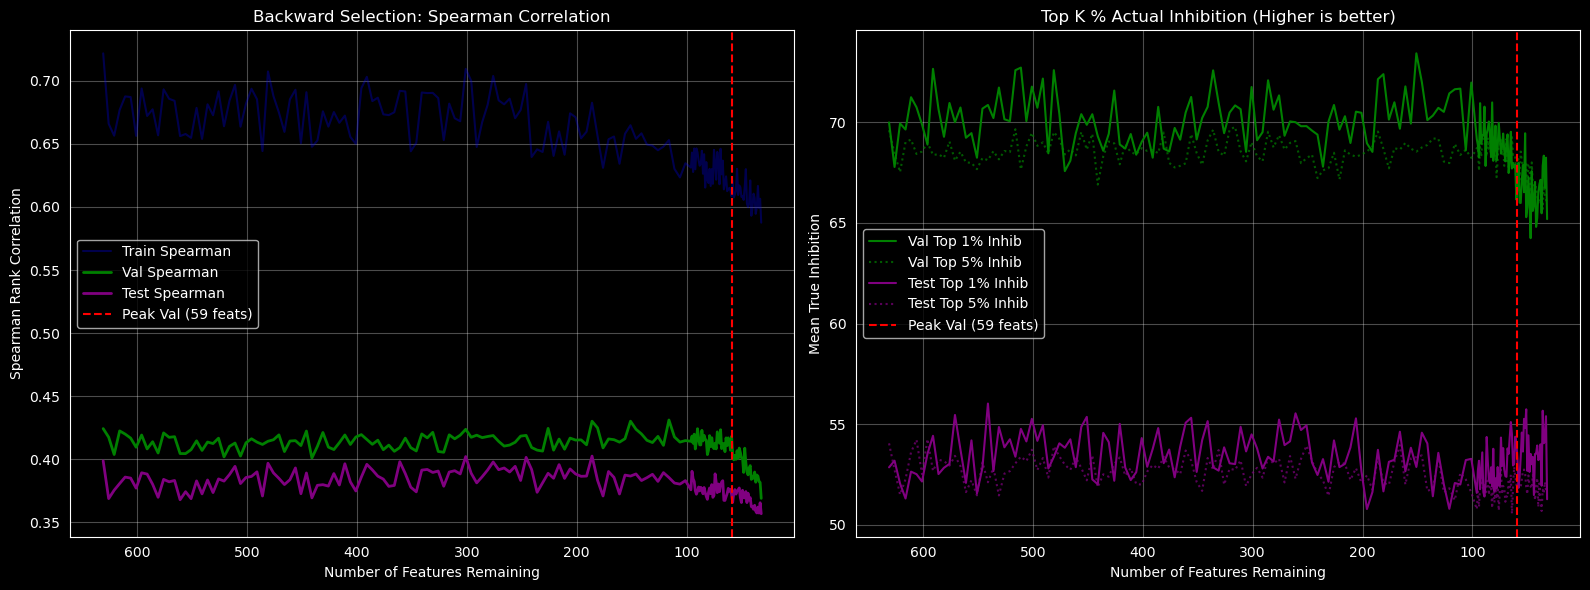

In [11]:
import matplotlib.pyplot as plt

# Retrieve optimal feature count for the marker line
opt_feat_count = best_row['num_features']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Spearman Correlation ---
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['train_spearman'], label='Train Spearman',
             color='blue', alpha=0.3)
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['val_spearman'], label='Val Spearman',
             color='green', linewidth=2)
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['test_spearman'], label='Test Spearman',
             color='purple', linewidth=2)
axes[0].axvline(x=opt_feat_count, color='red', linestyle='--', label=f'Peak Val ({opt_feat_count} feats)')

axes[0].invert_xaxis()
axes[0].set_title("Backward Selection: Spearman Correlation")
axes[0].set_xlabel("Number of Features Remaining")
axes[0].set_ylabel("Spearman Rank Correlation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Top K Performance ---
# Showing Validation & Test Top 1% and 5% Mean Inhibitions
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['val_top1'], label='Val Top 1% Inhib',
             color='green', linestyle='-')
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['val_top5'], label='Val Top 5% Inhib',
             color='green', linestyle=':', alpha=0.7)
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['test_top1'], label='Test Top 1% Inhib',
             color='purple', linestyle='-')
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['test_top5'], label='Test Top 5% Inhib',
             color='purple', linestyle=':', alpha=0.7)
axes[1].axvline(x=opt_feat_count, color='red', linestyle='--', label=f'Peak Val ({opt_feat_count} feats)')

axes[1].invert_xaxis()
axes[1].set_title("Top K % Actual Inhibition (Higher is better)")
axes[1].set_xlabel("Number of Features Remaining")
axes[1].set_ylabel("Mean True Inhibition")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
from tqdm.auto import tqdm

# Ensure optimal_features is defined from the backward selection step
optimal_features = best_row['features_list']

print(f"Training final GlobalModel with {len(optimal_features)} optimal features...")

# 1. Build Native DMatrices
opt_idxs = [feat_to_idx[f] for f in optimal_features]
dtrain_global = xgb.DMatrix(X_train_np[:, opt_idxs], label=y_train_np, feature_names=optimal_features)
dval_global = xgb.DMatrix(X_val_np[:, opt_idxs], label=y_val_np, feature_names=optimal_features)

# 2. Train Global Model
GlobalModel = xgb.train(
    best_l2_params,
    dtrain_global,
    num_boost_round=num_rounds,
    evals=[(dval_global, 'val')],
    early_stopping_rounds=50,
    verbose_eval=False
)

# 3. Save to Disk
GlobalModel.save_model("UnseenModel.json")
print("✅ Model saved successfully as 'UnseenModel.json'")

# 4. Extract Native XGBoost Gain
imp_gain = GlobalModel.get_score(importance_type='gain')
df_gain = pd.DataFrame(list(imp_gain.items()), columns=['Feature', 'Gain'])
df_gain = df_gain.sort_values(by='Gain', ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Group-Aware Permutation Importance
# ---------------------------------------------------------
print("\nCalculating Group-Aware Permutation Importance on Validation Set...")

baseline_preds = GlobalModel.predict(dval_global)
baseline_spearman = calculate_metrics(baseline_preds, y_val_np, val_eval_idx)['spearman']

df_eval = val_df[['cohort_id'] + optimal_features].copy()
perm_results = []

for feature in tqdm(optimal_features, desc="Permuting Features"):
    X_shuffled_np = X_val_np[:, opt_idxs].copy()
    feat_idx_in_shuffled = optimal_features.index(feature)

    # Check if the feature is perfectly constant within every single cohort_id
    is_constant = df_eval.groupby('cohort_id')[feature].nunique().max() == 1

    if is_constant:
        # --- COHORT-LEVEL SWAP ---
        cohort_mapping = df_eval[['cohort_id', feature]].drop_duplicates().reset_index(drop=True)
        cohort_mapping['shuffled_val'] = np.random.permutation(cohort_mapping[feature].values)
        shuffled_col = df_eval['cohort_id'].map(cohort_mapping.set_index('cohort_id')['shuffled_val'])

        X_shuffled_np[:, feat_idx_in_shuffled] = shuffled_col.values
        perm_type = "Cohort-Level"
    else:
        # --- ROW-LEVEL SWAP ---
        X_shuffled_np[:, feat_idx_in_shuffled] = np.random.permutation(X_shuffled_np[:, feat_idx_in_shuffled])
        perm_type = "Row-Level"

    dtemp = xgb.DMatrix(X_shuffled_np, feature_names=optimal_features)
    shuffled_preds = GlobalModel.predict(dtemp)
    shuffled_spearman = calculate_metrics(shuffled_preds, y_val_np, val_eval_idx)['spearman']

    perm_results.append({
        'Feature': feature,
        'Importance_Drop': baseline_spearman - shuffled_spearman,
        'Permutation_Type': perm_type
    })

df_perm = pd.DataFrame(perm_results)

# Split into the two distinct tracking DataFrames
df_perm_cohort = df_perm[df_perm['Permutation_Type'] == 'Cohort-Level'].sort_values(by='Importance_Drop',
                                                                                    ascending=False).reset_index(
    drop=True)
df_perm_row = df_perm[df_perm['Permutation_Type'] == 'Row-Level'].sort_values(by='Importance_Drop',
                                                                              ascending=False).reset_index(drop=True)

Training final GlobalModel with 59 optimal features...
✅ Model saved successfully as 'UnseenModel.json'

Calculating Group-Aware Permutation Importance on Validation Set...


Permuting Features:   0%|          | 0/59 [00:00<?, ?it/s]

/tmp/ipykernel_1123029/4096555688.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gain', y='Feature', data=df_gain.head(TOP_N), ax=axes[0], palette='viridis')
/tmp/ipykernel_1123029/4096555688.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_cohort.head(TOP_N), ax=axes[1], palette='flare')
/tmp/ipykernel_1123029/4096555688.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_row.head(TOP_N), ax=axes[2], palette='crest')


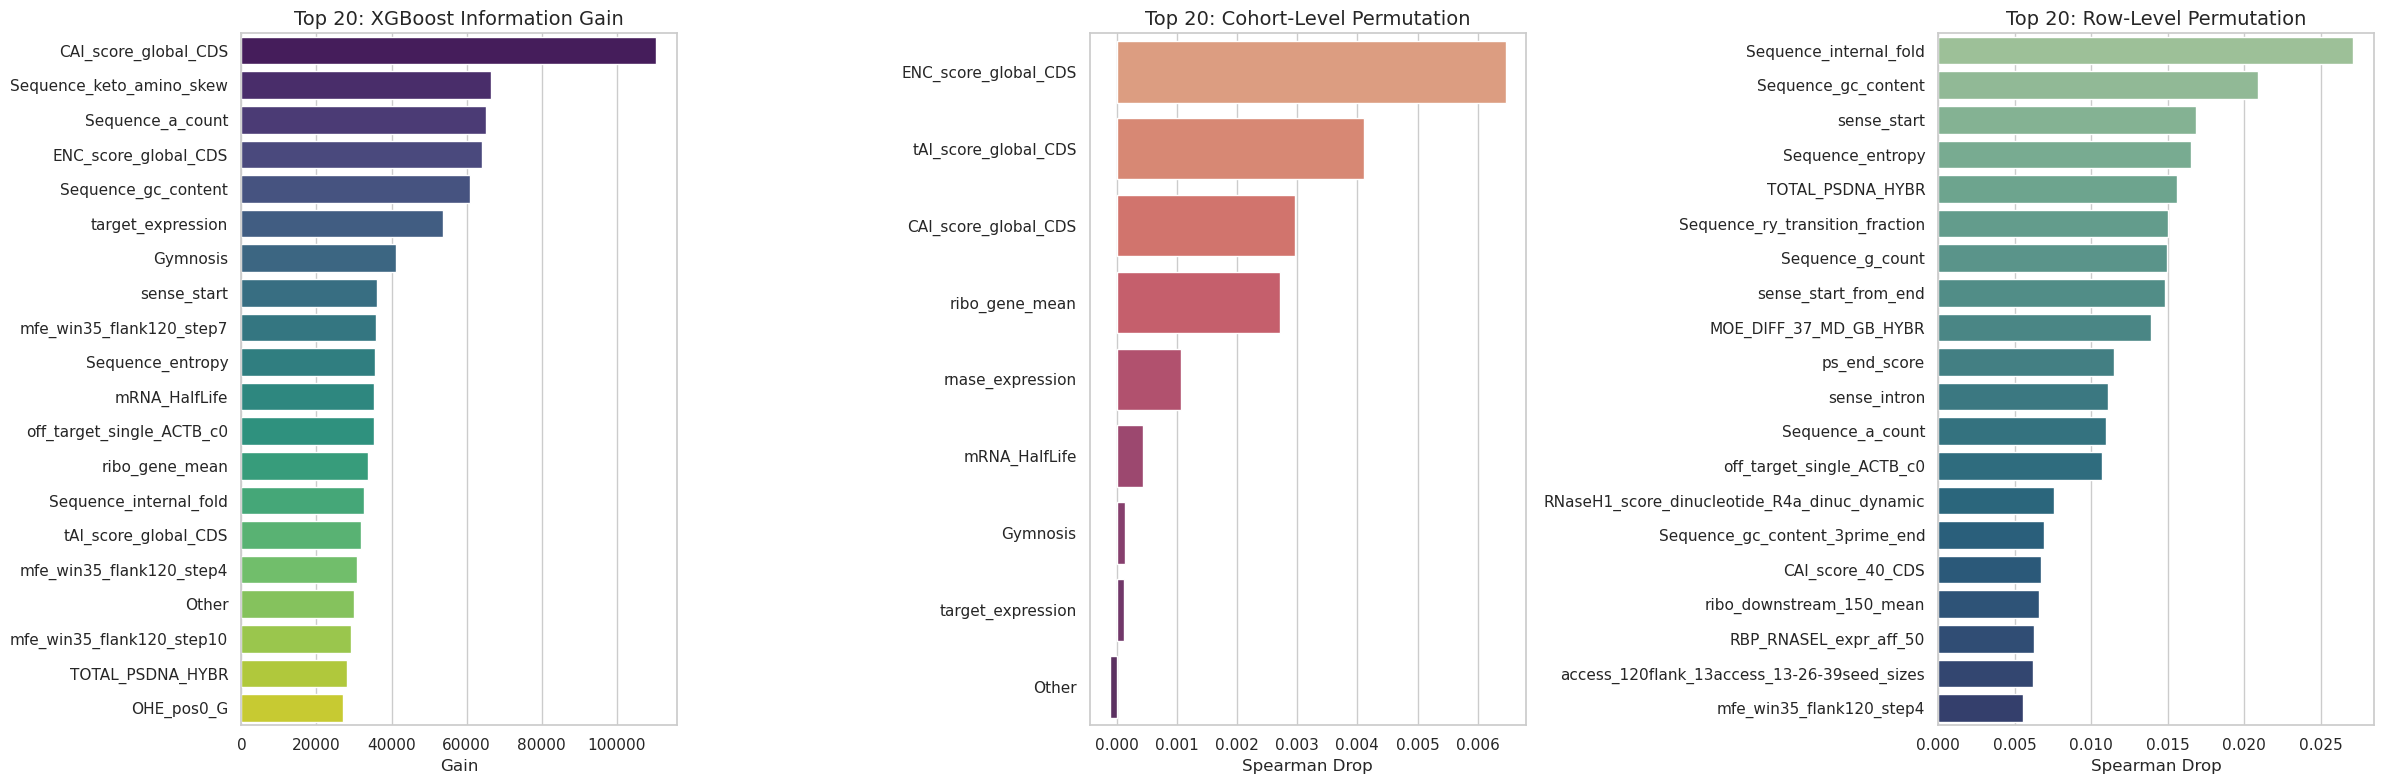


ALL FEATURES: NATIVE XGBOOST GAIN
                                     Feature          Gain
                        CAI_score_global_CDS 110583.781250
                    Sequence_keto_amino_skew  66513.015625
                            Sequence_a_count  65214.539062
                        ENC_score_global_CDS  64123.285156
                         Sequence_gc_content  60996.191406
                           target_expression  53816.738281
                                    Gymnosis  41093.191406
                                 sense_start  36030.250000
                    mfe_win35_flank120_step7  35899.125000
                            Sequence_entropy  35483.203125
                               mRNA_HalfLife  35443.539062
                   off_target_single_ACTB_c0  35373.250000
                              ribo_gene_mean  33835.570312
                      Sequence_internal_fold  32572.419922
                        tAI_score_global_CDS  31739.433594
                    m

/tmp/ipykernel_1123029/4096555688.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


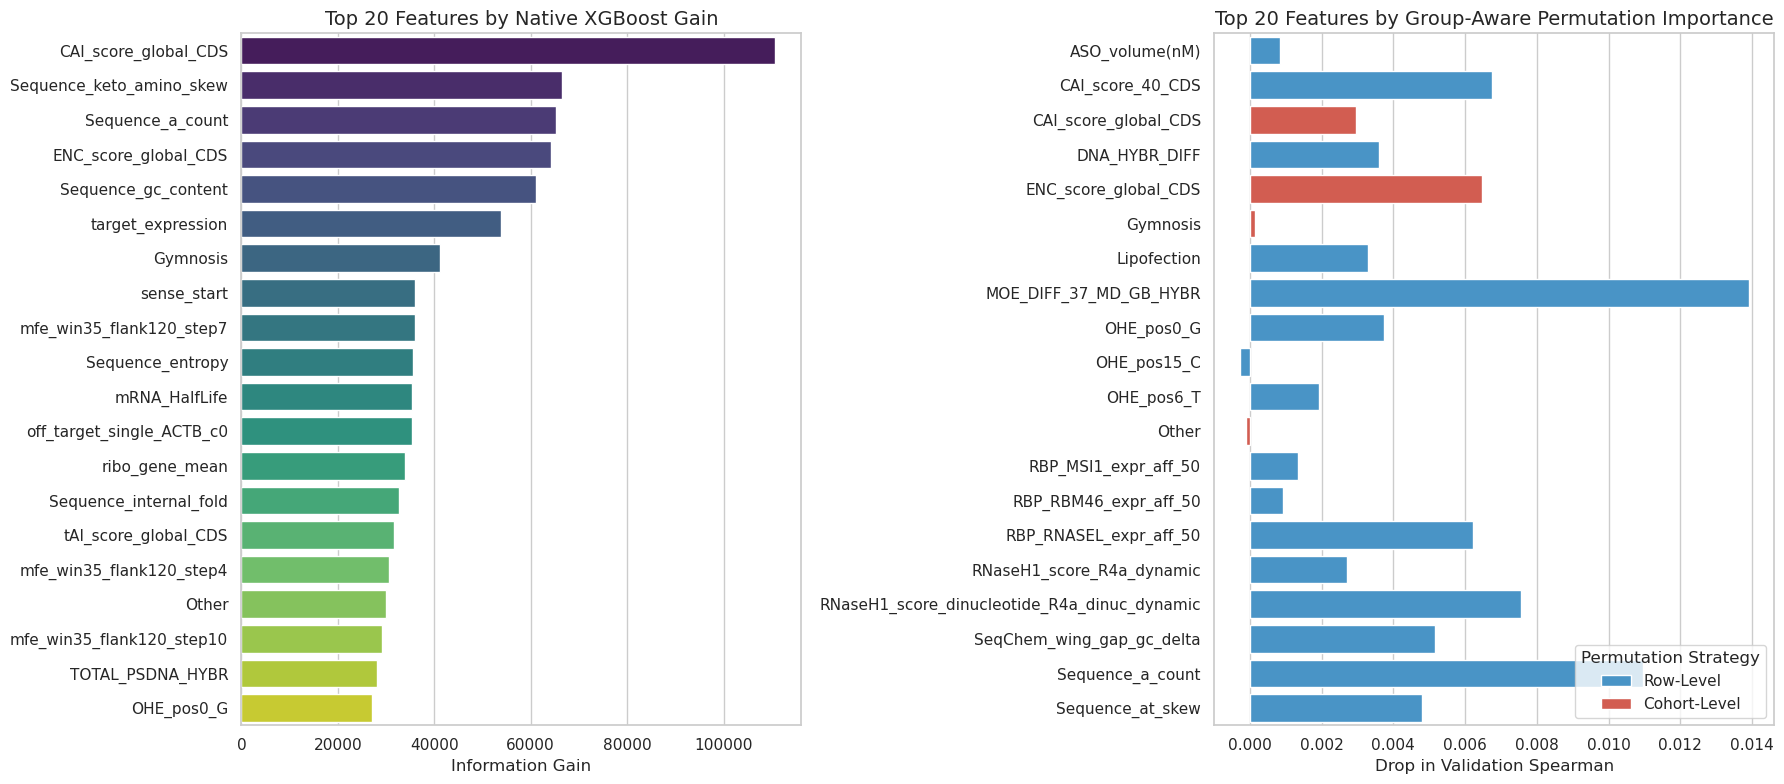


--- Top 10 Most Critical Features (Permutation) ---
               Feature  Importance_Drop Permutation_Type
        ASO_volume(nM)         0.000850        Row-Level
      CAI_score_40_CDS         0.006738        Row-Level
  CAI_score_global_CDS         0.002966     Cohort-Level
         DNA_HYBR_DIFF         0.003599        Row-Level
  ENC_score_global_CDS         0.006465     Cohort-Level
              Gymnosis         0.000136     Cohort-Level
           Lipofection         0.003282        Row-Level
MOE_DIFF_37_MD_GB_HYBR         0.013904        Row-Level
            OHE_pos0_G         0.003731        Row-Level
           OHE_pos15_C        -0.000289        Row-Level


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
TOP_N = 20

# --- Plot 1: XGBoost Gain ---
sns.barplot(x='Gain', y='Feature', data=df_gain.head(TOP_N), ax=axes[0], palette='viridis')
axes[0].set_title(f"Top {TOP_N}: XGBoost Information Gain", fontsize=14)
axes[0].set_xlabel("Gain")
axes[0].set_ylabel("")

# --- Plot 2: Cohort-Level Permutation ---
sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_cohort.head(TOP_N), ax=axes[1], palette='flare')
axes[1].set_title(f"Top {TOP_N}: Cohort-Level Permutation", fontsize=14)
axes[1].set_xlabel("Spearman Drop")
axes[1].set_ylabel("")

# --- Plot 3: Row-Level Permutation ---
sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_row.head(TOP_N), ax=axes[2], palette='crest')
axes[2].set_title(f"Top {TOP_N}: Row-Level Permutation", fontsize=14)
axes[2].set_xlabel("Spearman Drop")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print Exhaustive Descending Lists
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("ALL FEATURES: NATIVE XGBOOST GAIN")
print("=" * 60)
print(df_gain.to_string(index=False))

print("\n" + "=" * 60)
print("ALL FEATURES: COHORT-LEVEL PERMUTATION IMPORTANCE")
print("(Features constant across a cohort)")
print("=" * 60)
print(df_perm_cohort[['Feature', 'Importance_Drop']].to_string(index=False))

print("\n" + "=" * 60)
print("ALL FEATURES: ROW-LEVEL PERMUTATION IMPORTANCE")
print("(Features that vary within a cohort)")
print("=" * 60)
print(df_perm_row[['Feature', 'Importance_Drop']].to_string(index=False))
# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="whitegrid")

# Top 20 Features to plot
TOP_N = 20

# --- Plot 1: Native XGBoost Gain ---
sns.barplot(
    x='Gain', y='Feature',
    data=df_gain.head(TOP_N),
    ax=axes[0], palette='viridis'
)
axes[0].set_title(f"Top {TOP_N} Features by Native XGBoost Gain", fontsize=14)
axes[0].set_xlabel("Information Gain")
axes[0].set_ylabel("")

# --- Plot 2: Permutation Importance ---
# We use 'hue' to color-code whether the feature was swapped by Cohort or Row
sns.barplot(
    x='Importance_Drop', y='Feature',
    hue='Permutation_Type', dodge=False,
    data=df_perm.head(TOP_N),
    ax=axes[1], palette={'Cohort-Level': '#e74c3c', 'Row-Level': '#3498db'}
)
axes[1].set_title(f"Top {TOP_N} Features by Group-Aware Permutation Importance", fontsize=14)
axes[1].set_xlabel("Drop in Validation Spearman")
axes[1].set_ylabel("")
axes[1].legend(title="Permutation Strategy", loc="lower right")

plt.tight_layout()
plt.show()

# Print summary of the top features
print("\n--- Top 10 Most Critical Features (Permutation) ---")
print(df_perm.head(10).to_string(index=False))